# Notebook 07 — Random Forest under multiple evaluation strategies

**Goal:** Add Random Forest to the cell-by-cell comparison alongside Lasso 
(Notebook 05) and XGBoost (Notebook 06), under the same 4 new evaluation strategies.


| Strategy | Folds | Question it answers |
|---|---|---|
| `temporal_holdout` | 1 | Forward-in-time generalisation (last 20% by date) |
| `temporal_blocked_kfold` | 5 | Generalisation to held-out time blocks |
| `leave_one_site_out` | 14 | Generalisation to a never-seen sampling site |
| `random_kfold` |

  
**Grid:** 3 targets × 3 input configurations × 4 new strategies = **36 new runs**.

**Setup (parallel to XGBoost in Notebook 06):**
- Model: `RandomForestRegressor` on CPU with `n_jobs=-1` (sklearn has no GPU build).
- Inner CV: `GridSearchCV(cv=5)` over 12 hyperparameter combinations
  (`n_estimators × max_depth × min_samples_leaf`).
- Targets: temperature, salinity, Chl_a_log1p.
- Inputs: 16S clean, 18S clean, combined 16S+18S.

**Output:** `results/phase1_random_forest_3targets_3inputs_4strategies.csv`

In [1]:
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd

# Make src/ importable
sys.path.insert(0, str(Path('..').resolve()))

from src.cv_strategies import (
    random_kfold,
    temporal_holdout,
    temporal_blocked_kfold,
    leave_one_site_out,
)
from src.random_forest_evaluator import (
    run_random_forest_with_splits,
    RF_PARAM_GRID,
)

import sklearn
print(f'NumPy:        {np.__version__}')
print(f'pandas:       {pd.__version__}')
print(f'scikit-learn: {sklearn.__version__}')
print()
print(f'Grid: {RF_PARAM_GRID}')
n_combos = (len(RF_PARAM_GRID['n_estimators'])
            * len(RF_PARAM_GRID['max_depth'])
            * len(RF_PARAM_GRID['min_samples_leaf']))
print(f'Combinations per outer fold: {n_combos}')

NumPy:        2.4.4
pandas:       3.0.2
scikit-learn: 1.8.0

Grid: {'n_estimators': [200, 500], 'max_depth': [None, 10, 20], 'min_samples_leaf': [1, 5]}
Combinations per outer fold: 12


In [3]:
# Load all cleaned tables produced by Notebook 02 (with log1p applied)
PROCESSED_DIR = Path("../data/processed")

meta    = pd.read_csv(PROCESSED_DIR / "meta_clean.csv",    index_col=0)
otu_16s = pd.read_csv(PROCESSED_DIR / "otu_16s_clean.csv", index_col=0)
otu_18s = pd.read_csv(PROCESSED_DIR / "otu_18s_clean.csv", index_col=0)

# Build combined matrix (same as in Notebooks 03, 05, and 06)
otu_combined = pd.concat([otu_16s, otu_18s], axis=1)

# Sanity checks
assert (meta.index == otu_16s.index).all(),  "meta vs 16S misaligned"
assert (meta.index == otu_18s.index).all(),  "meta vs 18S misaligned"
assert otu_combined.columns.is_unique,        "duplicate columns in combined"
assert 'Chl_a_log1p' in meta.columns,         "Chl_a_log1p column missing — re-run Notebook 02"

print(f"meta:         {meta.shape}")
print(f"otu_16s:      {otu_16s.shape}")
print(f"otu_18s:      {otu_18s.shape}")
print(f"otu_combined: {otu_combined.shape}")
print(f"\n✓ All tables aligned.")
print(f"✓ Chl_a_log1p column is available in meta.")

meta:         (1538, 24)
otu_16s:      (1538, 1236)
otu_18s:      (1538, 1054)
otu_combined: (1538, 2290)

✓ All tables aligned.
✓ Chl_a_log1p column is available in meta.


In [5]:
RANDOM_SEED = 42

# Map (target_column, log_target_flag) for each target.
# Chl_a uses the pre-transformed Chl_a_log1p column from Notebook 02,
# so log_target=False here (the log is already done).
TARGETS = [
    {'name': 'temperature',   'col': 'temperature',  'log': False},
    {'name': 'salinity',      'col': 'salinity',     'log': False},
    {'name': 'Chl_a (log1p)', 'col': 'Chl_a_log1p',  'log': False},
]

# Map input name → DataFrame
INPUTS = {
    '16S':     otu_16s,
    '18S':     otu_18s,
    '16S+18S': otu_combined,
}

# All 4 strategies — random_kfold INCLUDED.
# Unlike Lasso (Notebook 05), we don't inherit random results from earlier work,
# because RF random_kfold was only run for temperature × 16S in Notebook 02.
# Running all 4 here gives us a complete 9-cell × 4-strategy table for RF.
STRATEGIES = ['random_kfold', 'temporal_holdout', 'temporal_blocked_kfold', 'leave_one_site_out']

all_rows = []

total_runs = len(TARGETS) * len(INPUTS) * len(STRATEGIES)
print(f'Random seed:    {RANDOM_SEED}')
print(f"Targets ({len(TARGETS)}):     {[t['name'] for t in TARGETS]}")
print(f'Inputs ({len(INPUTS)}):      {list(INPUTS.keys())}')
print(f'Strategies ({len(STRATEGIES)}):  {STRATEGIES}')
print(f'\nTotal new runs to do: {total_runs} = '
      f'{len(TARGETS)} × {len(INPUTS)} × {len(STRATEGIES)}')

Random seed:    42
Targets (3):     ['temperature', 'salinity', 'Chl_a (log1p)']
Inputs (3):      ['16S', '18S', '16S+18S']
Strategies (4):  ['random_kfold', 'temporal_holdout', 'temporal_blocked_kfold', 'leave_one_site_out']

Total new runs to do: 36 = 3 × 3 × 4


In [6]:
def build_splits(strategy_name, meta_valid, random_seed=42):
    """
    Dispatch to the right cv_strategies function based on strategy name.
    Returns a list of (train_idx, test_idx) tuples — indices into meta_valid.
    """
    n = len(meta_valid)

    if strategy_name == 'random_kfold':
        return random_kfold(n_samples=n, n_folds=5, random_seed=random_seed)

    elif strategy_name == 'temporal_holdout':
        return temporal_holdout(meta_valid, test_fraction=0.2)

    elif strategy_name == 'temporal_blocked_kfold':
        return temporal_blocked_kfold(meta_valid, n_folds=5)

    elif strategy_name == 'leave_one_site_out':
        return leave_one_site_out(meta_valid)

    else:
        raise ValueError(f"Unknown strategy: {strategy_name}")


# Quick dispatch test on temperature target
_test_valid_mask = meta['temperature'].notna()
_test_meta_valid = meta.loc[_test_valid_mask].reset_index(drop=True)
print("Quick dispatch test on temperature target:")
for s in STRATEGIES:
    splits = build_splits(s, _test_meta_valid, RANDOM_SEED)
    print(f"  {s:30s}  →  {len(splits)} folds")

Quick dispatch test on temperature target:
  random_kfold                    →  5 folds
  temporal_holdout                →  1 folds
  temporal_blocked_kfold          →  5 folds
  leave_one_site_out              →  14 folds


In [10]:
# ============================================================
# Smoke test — validate the pipeline end-to-end on ONE combination
# before running the full 36-cell grid.
#
# Chosen combination: temperature × 16S × temporal_holdout
#   - temperature: well-understood target (prior result from Notebook 02: R²=0.967 random)
#   - 16S: smallest input matrix (fastest)
#   - temporal_holdout: only 1 fold (fastest strategy)
#
# Expected runtime: 3–8 minutes on CPU (vs 1–3 min for XGBoost on GPU).
# If this completes successfully, the full grid will work too.
# ============================================================

# Filter to valid samples for temperature
target_col = 'temperature'
valid_mask = meta[target_col].notna()
meta_v = meta.loc[valid_mask].reset_index(drop=True)
otu_v  = otu_16s.loc[valid_mask].reset_index(drop=True)

print(f"Valid samples for {target_col}: {len(meta_v)}")

# Build splits for the simplest strategy
splits = build_splits('temporal_holdout', meta_v, RANDOM_SEED)

# Run the evaluator
t0 = time.time()
res_smoke = run_random_forest_with_splits(
    target_name   = target_col,
    meta          = meta_v,
    otu           = otu_v,
    splits        = splits,
    strategy_name = 'temporal_holdout',
    input_name    = '16S',
    log_target    = False,
    random_seed   = RANDOM_SEED,
    verbose       = True,
)
elapsed = time.time() - t0

print(f"\n{'=' * 64}")
print(f"Smoke test complete in {elapsed:.1f}s ({elapsed/60:.1f} min).")
print(f"R²    = {res_smoke['r2_mean']:+.4f}")
print(f"MAE   = {res_smoke['mae_mean']:.3f} °C")
print(f"RMSE  = {res_smoke['rmse_mean']:.3f} °C")
print(f"Best params (mode): "
      f"n_est={res_smoke['best_n_est_mode']}, "
      f"max_depth={res_smoke['best_max_depth_mode']}, "
      f"min_samples_leaf={res_smoke['best_min_samples_leaf_mode']}")

Valid samples for temperature: 1223

Target: temperature    Input features: 1236
  Samples: 1223    Folds: 1
  Strategy: temporal_holdout    Input: 16S


KeyboardInterrupt: 

In [ ]:
# ============================================================
# Main grid: 3 targets × 3 inputs × 4 strategies = 36 runs.
# Incremental CSV save after every run + resume support.
# ============================================================

OUTPUT_CSV = Path('../results/phase1_random_forest_3targets_3inputs_4strategies.csv')
OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)

CSV_COLS = [
    'target_display', 'target', 'input', 'strategy',
    'log_target', 'n_samples', 'n_features', 'n_folds',
    'r2_mean', 'r2_std',
    'mae_mean', 'mae_std',
    'rmse_mean', 'rmse_std',
    'best_n_est_mode', 'best_max_depth_mode', 'best_min_samples_leaf_mode',
    'total_time',
]


def save_partial(rows, path):
    if not rows:
        return
    df = pd.DataFrame(rows)[CSV_COLS].round({
        'r2_mean': 4,  'r2_std': 4,
        'mae_mean': 3, 'mae_std': 3,
        'rmse_mean': 3, 'rmse_std': 3,
        'total_time': 1,
    })
    df.to_csv(path, index=False)


# Resume: if CSV exists, skip cells already done
done_keys = set()
if OUTPUT_CSV.exists():
    prev = pd.read_csv(OUTPUT_CSV)
    done_keys = {(r['target'], r['input'], r['strategy']) for _, r in prev.iterrows()}
    all_rows  = prev.to_dict('records')
    print(f'Resuming: {len(done_keys)} cells already in CSV — they will be skipped.')
else:
    all_rows = []

t_global_start = time.time()
run_counter = 0

for target in TARGETS:
    target_name = target['name']
    target_col  = target['col']
    log_flag    = target['log']

    valid_mask  = meta[target_col].notna()
    meta_valid  = meta.loc[valid_mask].reset_index(drop=True)

    for input_name, otu_df in INPUTS.items():
        otu_valid = otu_df.loc[valid_mask].reset_index(drop=True)

        for strategy_name in STRATEGIES:
            run_counter += 1

            if (target_col, input_name, strategy_name) in done_keys:
                print(f'[skip {run_counter}/{total_runs}] '
                      f'{target_name} × {input_name} × {strategy_name}')
                continue

            elapsed_total = (time.time() - t_global_start) / 60
            print(f'\n{"#" * 64}')
            print(f'# Run {run_counter}/{total_runs}  ·  elapsed so far: {elapsed_total:.1f} min')
            print(f'# target={target_name}  input={input_name}  strategy={strategy_name}')
            print(f'{"#" * 64}')

            splits = build_splits(strategy_name, meta_valid, RANDOM_SEED)

            res = run_random_forest_with_splits(
                target_name   = target_col,
                meta          = meta_valid,
                otu           = otu_valid,
                splits        = splits,
                strategy_name = strategy_name,
                input_name    = input_name,
                log_target    = log_flag,
                random_seed   = RANDOM_SEED,
                verbose       = True,
            )
            res['target_display'] = target_name
            all_rows.append(res)

            save_partial(all_rows, OUTPUT_CSV)
            print(f'  → partial results saved ({len(all_rows)}/{total_runs} rows in CSV)')

t_global_end = time.time()
total_min    = (t_global_end - t_global_start) / 60

print(f'\n{"=" * 64}')
print(f'All {total_runs} runs complete in {total_min:.1f} minutes ({total_min/60:.1f} hours).')
print(f'Final CSV: {OUTPUT_CSV}')

In [ ]:
results = pd.read_csv(OUTPUT_CSV)
print(f'Total cells: {len(results)} / {total_runs}')
print()

pivot = results.pivot_table(
    index=['target_display', 'input'],
    columns='strategy',
    values='r2_mean',
)[STRATEGIES]    # column order: random, holdout, blocked, LOSO

pivot.round(3)

In [ ]:
# Most-frequently selected hyperparameters per cell
# — sanity check that the grid covers the relevant regularisation regime
results[['target_display', 'input', 'strategy',
         'best_n_est_mode', 'best_max_depth_mode', 'best_min_samples_leaf_mode']]

## Section 2 — LOSO × salinity per-site breakdown

**Goal:** Confirm Finding 5 from the previous meeting (Muehlendamm hypothesis)
for the RF model.

The aggregate R² for `salinity × LOSO` was catastrophic (−26 to −60 across inputs),
but the meeting summary suggested this is driven by a single site — Muehlendamm —
which has a freshwater regime (~0.45 PSU) very different from the other 13 brackish
sites (5–24 PSU). Holding it out asks the model to extrapolate to an unseen ecological
regime, which neither linear nor tree-based models can do.

In this section we:
1. Build the site-fold mapping (which site = which fold of LOSO).
2. Extract per-fold R² values from the `verbose=True` output captured in
   `results/rf_run.log`.
3. Combine into a per-site table sorted by worst R².
4. Compare RF's failure mode at Muehlendamm to the same fold for Lasso/XGBoost
   from the previous meeting.

In [ ]:
# Build a mapping: fold number → site held out + that site's salinity stats.
# We re-run leave_one_site_out on the same valid-salinity subset to recover
# the exact site order used during the main run.اب سایت 6 شوری کمی داره برای همین نتایج منفی میشه

_salinity_mask  = meta['salinity'].notna()
_meta_salinity  = meta.loc[_salinity_mask].reset_index(drop=True)

# Detect site identifier column (canonical key) + human-readable name column
SITE_COL = None
for _c in ['location_id', 'site_id', 'site', 'Site', 'station', 'Station']:
    if _c in _meta_salinity.columns:
        SITE_COL = _c
        break
assert SITE_COL is not None, (
    f"No site ID column. Available: {list(_meta_salinity.columns)}"
)

NAME_COL = None
for _c in ['location_name', 'site_name', 'station_name']:
    if _c in _meta_salinity.columns:
        NAME_COL = _c
        break

_loso_splits = leave_one_site_out(_meta_salinity)

_fold_to_site = []
for _i, (_tr, _te) in enumerate(_loso_splits):
    _ids_in_test = _meta_salinity.iloc[_te][SITE_COL].unique()
    assert len(_ids_in_test) == 1, (
        f"Fold {_i+1}: expected one site, got {_ids_in_test}"
    )
    _sal_test = _meta_salinity.iloc[_te]['salinity']

    _record = {
        'fold':          _i + 1,
        'site_id':       _ids_in_test[0],
        'n_test':        len(_te),
        'salinity_mean': float(_sal_test.mean()),
        'salinity_std':  float(_sal_test.std()),
    }
    if NAME_COL:
        _record['site_name'] = str(_meta_salinity.iloc[_te][NAME_COL].iloc[0])
    _fold_to_site.append(_record)

site_df = pd.DataFrame(_fold_to_site)

print(f"Valid salinity samples: {len(_meta_salinity)}")
print(f"Site ID column:         '{SITE_COL}'")
print(f"Site name column:       '{NAME_COL or '(none)'}'")
print(f"LOSO folds:             {len(_loso_splits)}")
print()
print("Site-fold mapping:")
print(site_df.to_string(index=False))

Valid salinity samples: 1217
Site ID column:         'location_id'
Site name column:       'location_name'
LOSO folds:             14

Site-fold mapping:
 fold  site_id  n_test  salinity_mean  salinity_std               site_name
    1        3      87      14.851312      2.842467      Boergerende Strand
    2        6      84      14.659829      2.904260          Diedrichshagen
    3        5      82      14.679071      2.929565       Elmenhorst Strand
    4        2      88      14.607042      2.844812         Jemnitzschleuse
    5       15      88      14.643825      2.596178  Mittelmole Warnemuende
    6        8      90       0.446798      0.266014             Muehlendamm
    7       14      89      13.485564      3.303925            Neptun-Werft
    8       12      88      11.440450      4.601627    Parkplatz zur Warnow
    9       10      90      11.677599      4.765693       SAB Marina Bramow
   10       13      87      12.151399      4.399155 Schmarl-Dorf / IGA-Park
   11     

In [13]:
# Parse per-fold R² values for LOSO × salinity cells.
#
# Note: jupyter nbconvert --execute captures cell stdout into the executed
# notebook's cell.outputs (NOT into the log file). So we read the executed
# notebook JSON directly to recover the verbose fold output.

import json
import re

_exec_nb_path = Path('07_random_forest_evaluation_strategies_executed.ipynb')
_log_path     = Path('../results/rf_run.log')

_main_loop_text = ""

# Source 1: executed notebook (most reliable — captures cell stdout)
if _exec_nb_path.exists():
    print(f"Reading executed notebook: {_exec_nb_path}")
    with open(_exec_nb_path) as _f:
        _nb = json.load(_f)
    for _cell in _nb['cells']:
        if _cell['cell_type'] != 'code':
            continue
        _text = ""
        for _out in _cell.get('outputs', []):
            if _out.get('output_type') == 'stream':
                _text += ''.join(_out.get('text', []))
        if '# Run 1/36' in _text:
            _main_loop_text = _text
            print(f"  ✓ Found main loop output: {len(_main_loop_text):,} chars")
            break

# Source 2: log file (fallback)
if not _main_loop_text and _log_path.exists():
    _text = _log_path.read_text(encoding='utf-8', errors='replace')
    if '# Run 1/36' in _text:
        _main_loop_text = _text
        print(f"Falling back to log file: {_log_path}")
        print(f"  ✓ Found main loop output in log: {len(_main_loop_text):,} chars")

assert _main_loop_text, (
    "Couldn't find main loop output in executed notebook or log. "
    "Make sure nbconvert finished successfully."
)

# Extract per-fold R² for LOSO × salinity blocks
_header_re = re.compile(r'^# target=(.+?)\s+input=(\S+)\s+strategy=(\S+)', re.MULTILINE)
_fold_re   = re.compile(r'fold\s+(\d+)/(\d+)\s+R²=([+-][\d.]+)')

_matches = list(_header_re.finditer(_main_loop_text))
print(f"\nFound {len(_matches)} run sections in output")

loso_salinity_folds = {}
for _i, _m in enumerate(_matches):
    _target, _input, _strategy = _m.groups()
    if _target != 'salinity' or _strategy != 'leave_one_site_out':
        continue
    _start = _m.end()
    _end   = _matches[_i + 1].start() if _i + 1 < len(_matches) else len(_main_loop_text)
    _section = _main_loop_text[_start:_end]
    _folds = [
        {'fold': int(_fm.group(1)), 'r2': float(_fm.group(3))}
        for _fm in _fold_re.finditer(_section)
    ]
    if _folds:
        loso_salinity_folds[_input] = pd.DataFrame(_folds)
        print(f"  ✓ salinity × {_input}: {len(_folds)} folds")

# Validate
for _input in ['16S', '18S', '16S+18S']:
    assert _input in loso_salinity_folds, f"Missing data for input '{_input}'"
    assert len(loso_salinity_folds[_input]) == 14, (
        f"{_input}: expected 14 folds, got {len(loso_salinity_folds[_input])}"
    )

print(f"\n✓ All 3 LOSO × salinity cells loaded, 14 folds each.")

Reading executed notebook: 07_random_forest_evaluation_strategies_executed.ipynb
  ✓ Found main loop output: 56,504 chars

Found 36 run sections in output
  ✓ salinity × 16S: 14 folds
  ✓ salinity × 18S: 14 folds
  ✓ salinity × 16S+18S: 14 folds

✓ All 3 LOSO × salinity cells loaded, 14 folds each.


In [14]:
# Combine site_df (Cell 11) with loso_salinity_folds (Cell 12)
# into a single per-site table, sorted by worst R² across inputs.

combined = site_df.copy()

for _input_name in ['16S', '18S', '16S+18S']:
    _r2_by_fold = loso_salinity_folds[_input_name].set_index('fold')['r2']
    combined[f'r2_{_input_name}'] = combined['fold'].map(_r2_by_fold)

# Worst R² across the 3 inputs for each fold
_r2_cols = ['r2_16S', 'r2_18S', 'r2_16S+18S']
combined['r2_worst'] = combined[_r2_cols].min(axis=1)

# Sort: worst → best
combined = combined.sort_values('r2_worst').reset_index(drop=True)

# Pretty display
print("Per-site R² for LOSO × salinity (sorted: worst → best)")
print("=" * 100)
_display_cols = ['site_name', 'n_test', 'salinity_mean', 'salinity_std',
                 'r2_16S', 'r2_18S', 'r2_16S+18S', 'r2_worst']
print(combined[_display_cols].to_string(
    index=False,
    formatters={
        'salinity_mean': '{:+6.2f}'.format,
        'salinity_std':  '{:5.2f}'.format,
        'r2_16S':        '{:+9.2f}'.format,
        'r2_18S':        '{:+9.2f}'.format,
        'r2_16S+18S':    '{:+9.2f}'.format,
        'r2_worst':      '{:+9.2f}'.format,
    },
))

Per-site R² for LOSO × salinity (sorted: worst → best)
              site_name  n_test salinity_mean salinity_std    r2_16S    r2_18S r2_16S+18S  r2_worst
            Muehlendamm      90         +0.45         0.27   -379.77   -852.18    -430.54   -852.18
 Mittelmole Warnemuende      88        +14.64         2.60     +0.59     +0.58      +0.58     +0.58
         Diedrichshagen      84        +14.66         2.90     +0.88     +0.67      +0.85     +0.67
        Jemnitzschleuse      88        +14.61         2.84     +0.86     +0.76      +0.86     +0.76
      Elmenhorst Strand      82        +14.68         2.93     +0.89     +0.76      +0.91     +0.76
     Warnemuende Strand      84        +14.85         2.88     +0.91     +0.80      +0.90     +0.80
     Stadthafen Rostock      89         +9.05         5.55     +0.88     +0.81      +0.88     +0.81
  Steilkueste Nienhagen      85        +14.70         2.88     +0.91     +0.81      +0.92     +0.81
           Neptun-Werft      89        +13.49

In [15]:
# Headline statistics: with and without the Muehlendamm fold.
# This computes the "brackish 13" vs "all 14" comparison that the meeting
# summary proposed as option B for reporting LOSO results.

_worst_site = combined.iloc[0]['site_name']
_others     = combined.iloc[1:]   # 13 brackish sites
_r2_cols    = ['r2_16S', 'r2_18S', 'r2_16S+18S']

print("=" * 80)
print(f"LOSO × salinity headline:  {_worst_site}  vs  the other 13 sites")
print("=" * 80)

# 1. Worst fold (Muehlendamm)
print(f"\nWorst fold:  {_worst_site}")
print(f"  salinity at site: {combined.iloc[0]['salinity_mean']:+.2f} ± "
      f"{combined.iloc[0]['salinity_std']:.2f} PSU  ({combined.iloc[0]['n_test']} samples)")
print(f"  R² per input:  16S={combined.iloc[0]['r2_16S']:+.1f}   "
      f"18S={combined.iloc[0]['r2_18S']:+.1f}   "
      f"16S+18S={combined.iloc[0]['r2_16S+18S']:+.1f}")

# 2. The other 13 sites
print(f"\nOther 13 sites  (salinity range {_others['salinity_mean'].min():+.2f} "
      f"→ {_others['salinity_mean'].max():+.2f} PSU):")
print(f"  R² median per input:")
for _col in _r2_cols:
    _med = _others[_col].median()
    _min = _others[_col].min()
    _max = _others[_col].max()
    print(f"    {_col:12s}  median={_med:+.3f}   range=[{_min:+.3f}, {_max:+.3f}]")

# 3. Aggregate comparison — with Muehlendamm vs without
print(f"\nAggregate R² (mean across folds):")
print(f"  {'Input':<12}  {'all 14 folds':>15}    {'excluding ' + _worst_site:>30}")
for _col in _r2_cols:
    _with_all      = combined[_col].mean()
    _without_worst = _others[_col].mean()
    print(f"  {_col:<12}  {_with_all:+15.2f}    {_without_worst:+30.3f}")

# 4. Save the per-site table for the meeting deck and thesis
_out_path = Path('../results/loso_salinity_per_site_rf.csv')
combined.to_csv(_out_path, index=False)
print(f"\n✓ Saved per-site table to: {_out_path}")
print(f"   ({len(combined)} rows, {len(combined.columns)} columns)")

LOSO × salinity headline:  Muehlendamm  vs  the other 13 sites

Worst fold:  Muehlendamm
  salinity at site: +0.45 ± 0.27 PSU  (90 samples)
  R² per input:  16S=-379.8   18S=-852.2   16S+18S=-430.5

Other 13 sites  (salinity range +9.05 → +14.85 PSU):
  R² median per input:
    r2_16S        median=+0.901   range=[+0.589, +0.964]
    r2_18S        median=+0.811   range=[+0.580, +0.933]
    r2_16S+18S    median=+0.907   range=[+0.584, +0.960]

Aggregate R² (mean across folds):
  Input            all 14 folds             excluding Muehlendamm
  r2_16S                 -26.31                            +0.883
  r2_18S                 -60.12                            +0.804
  r2_16S+18S             -29.94                            +0.880

✓ Saved per-site table to: ../results/loso_salinity_per_site_rf.csv
   (14 rows, 10 columns)


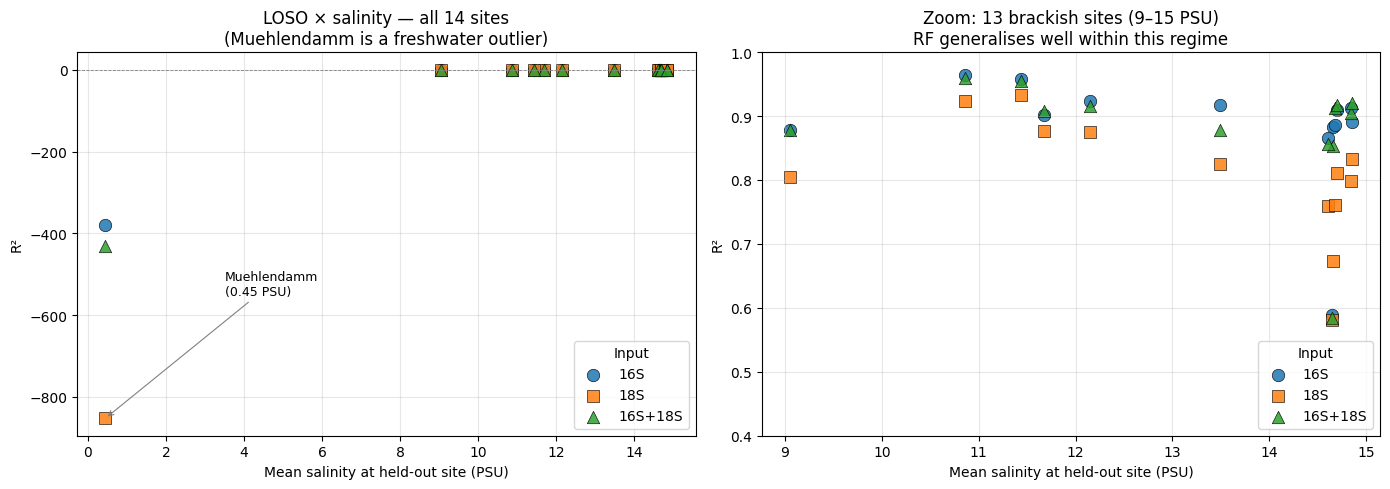


✓ Saved figure to: ../results/loso_salinity_per_site_rf.png


In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Marker style per input
_markers = {
    'r2_16S':     ('o', 'C0', '16S'),
    'r2_18S':     ('s', 'C1', '18S'),
    'r2_16S+18S': ('^', 'C2', '16S+18S'),
}

# ─── Panel A: all 14 sites (full y-range, Muehlendamm visible as outlier) ───
ax = axes[0]
for _col, (_m, _c, _lbl) in _markers.items():
    ax.scatter(combined['salinity_mean'], combined[_col],
               marker=_m, color=_c, s=80, label=_lbl,
               alpha=0.85, edgecolor='black', linewidth=0.5)
ax.axhline(0, color='gray', linewidth=0.6, linestyle='--')
ax.set_xlabel('Mean salinity at held-out site (PSU)')
ax.set_ylabel('R²')
ax.set_title('LOSO × salinity — all 14 sites\n(Muehlendamm is a freshwater outlier)')
ax.legend(title='Input', loc='lower right')
ax.grid(alpha=0.3)

# Annotate the worst site
_worst = combined.iloc[0]
ax.annotate(
    f"Muehlendamm\n({_worst['salinity_mean']:.2f} PSU)",
    xy=(_worst['salinity_mean'], _worst['r2_18S']),
    xytext=(3.5, -550),
    fontsize=9,
    arrowprops=dict(arrowstyle='->', color='gray', lw=0.8),
)

# ─── Panel B: zoom on the 13 brackish sites ─────────────────────────────────
ax = axes[1]
_brackish = combined[combined['site_name'] != _worst['site_name']]
for _col, (_m, _c, _lbl) in _markers.items():
    ax.scatter(_brackish['salinity_mean'], _brackish[_col],
               marker=_m, color=_c, s=80, label=_lbl,
               alpha=0.85, edgecolor='black', linewidth=0.5)
ax.set_xlabel('Mean salinity at held-out site (PSU)')
ax.set_ylabel('R²')
ax.set_ylim(0.4, 1.0)
ax.set_title('Zoom: 13 brackish sites (9–15 PSU)\nRF generalises well within this regime')
ax.legend(title='Input', loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()

# Save for the meeting
_fig_path = Path('../results/loso_salinity_per_site_rf.png')
plt.savefig(_fig_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved figure to: {_fig_path}")

## Section 3 — Three-model comparison: Lasso vs RF vs XGBoost

**Goal:** Bring all three baseline models into a single cell-by-cell comparison
(3 targets × 3 inputs × 4 strategies = 36 cells per model) and identify where
each model wins, ties, or loses.

The previous meeting summary reported "XGBoost wins every cell, 36 of 36"
against Lasso. With RF now added, the picture becomes more nuanced:
non-linearity is the dominant factor, but XGBoost's sequential error
correction matters specifically for **temporal extrapolation** of temperature.

In this section we:
1. Load the per-cell R² CSVs for all three models.
2. Build a unified long-form DataFrame: (target, input, strategy, model) → R².
3. Build a 9-cell × 4-strategy heatmap **per model** (3 panels side by side).
4. Build a **delta table** (RF − XGBoost) to identify where RF wins.
5. Highlight cells with negative R² (catastrophic failures) for honest reporting.

In [17]:
# Discover all Phase 1 results CSVs on disk before assembling the comparison.
# This tells us what's available for Lasso, XGBoost, and RF.

_results_dir = Path('../results')

print(f"Results directory: {_results_dir.resolve()}")
print(f"{'─' * 80}")

_phase1_csvs = sorted(_results_dir.glob('phase1_*.csv'))

if not _phase1_csvs:
    print("⚠️  No phase1_*.csv files found!")
else:
    for _f in _phase1_csvs:
        try:
            _df = pd.read_csv(_f)
            # Detect which strategies are in the file
            _strats = sorted(_df['strategy'].unique()) if 'strategy' in _df.columns else ['?']
            _targets = sorted(_df['target'].unique()) if 'target' in _df.columns else ['?']
            _inputs  = sorted(_df['input'].unique())  if 'input'  in _df.columns else ['?']
            print(f"\n📄 {_f.name}")
            print(f"   rows: {len(_df)}")
            print(f"   targets:    {_targets}")
            print(f"   inputs:     {_inputs}")
            print(f"   strategies: {_strats}")
            print(f"   columns:    {list(_df.columns[:8])}{'...' if len(_df.columns) > 8 else ''}")
        except Exception as _e:
            print(f"\n📄 {_f.name}  — ERROR reading: {_e}")

Results directory: /mnt/data/home/tv2414/tabpfn_project/results
────────────────────────────────────────────────────────────────────────────────

📄 phase1_baselines_3targets_16s.csv
   rows: 7
   targets:    ['Chl_a', 'salinity', 'temperature']
   inputs:     ['?']
   strategies: ['?']
   columns:    ['model', 'target', 'transform', 'n_samples', 'r2_mean', 'r2_std', 'mae_mean', 'mae_std']...

📄 phase1_comparison_lasso_vs_xgboost.csv
   rows: 54
   targets:    ['Chl_a (log1p)', 'Chl_a_log1p', 'salinity', 'temperature']
   inputs:     ['16S', '16S+18S', '18S']
   strategies: ['leave_one_site_out', 'temporal_blocked_kfold', 'temporal_holdout']
   columns:    ['strategy', 'input', 'target', 'n_folds', 'n_samples', 'n_features', 'r2_mean', 'r2_std']...

📄 phase1_lasso_3newstrategies.csv
   rows: 27
   targets:    ['Chl_a (log1p)', 'salinity', 'temperature']
   inputs:     ['16S', '16S+18S', '18S']
   strategies: ['leave_one_site_out', 'temporal_blocked_kfold', 'temporal_holdout']
   columns

In [18]:
# Load all three models' 36-cell CSVs and unify into a long-form comparison table.

_results_dir = Path('../results')
_lasso_path  = _results_dir / 'phase1_lasso_3targets_3inputs_4strategies.csv'
_xgb_path    = _results_dir / 'phase1_xgboost_3targets_3inputs_4strategies.csv'
_rf_path     = _results_dir / 'phase1_random_forest_3targets_3inputs_4strategies.csv'

# Sanity: all three files exist
for _model, _path in [('Lasso', _lasso_path), ('XGBoost', _xgb_path), ('RF', _rf_path)]:
    assert _path.exists(), f"Missing: {_path}"

_lasso_df = pd.read_csv(_lasso_path)
_xgb_df   = pd.read_csv(_xgb_path)
_rf_df    = pd.read_csv(_rf_path)
print(f"Loaded:  Lasso ({len(_lasso_df)})  XGBoost ({len(_xgb_df)})  RF ({len(_rf_df)})")


def _normalize_model_df(df, model_name):
    """Extract a common subset of columns + add the model column.

    Use 'target_display' if available (canonical human-readable name).
    Otherwise 'target' column already is the display name (Lasso CSV)."""
    out = df.copy()
    if 'target_display' in out.columns:
        out = out.rename(columns={'target_display': 'target_name'}).drop(columns=['target'])
    else:
        out = out.rename(columns={'target': 'target_name'})
    out = out[['target_name', 'input', 'strategy', 'r2_mean']].copy()
    out['model'] = model_name
    return out


comparison_df = pd.concat([
    _normalize_model_df(_lasso_df, 'Lasso'),
    _normalize_model_df(_rf_df,    'RF'),
    _normalize_model_df(_xgb_df,   'XGBoost'),
], ignore_index=True)

# Validation
assert len(comparison_df) == 36 * 3, f"Expected 108 rows, got {len(comparison_df)}"

_targets_set    = sorted(comparison_df['target_name'].unique())
_inputs_set     = sorted(comparison_df['input'].unique())
_strategies_set = sorted(comparison_df['strategy'].unique())
_models_set     = sorted(comparison_df['model'].unique())

print(f"\nUnified comparison_df: {len(comparison_df)} rows")
print(f"  Targets    ({len(_targets_set)}):  {_targets_set}")
print(f"  Inputs     ({len(_inputs_set)}):  {_inputs_set}")
print(f"  Strategies ({len(_strategies_set)}):  {_strategies_set}")
print(f"  Models     ({len(_models_set)}):  {_models_set}")

print(f"\nFirst 6 rows:")
print(comparison_df.head(6).to_string(index=False))

Loaded:  Lasso (36)  XGBoost (36)  RF (36)

Unified comparison_df: 108 rows
  Targets    (3):  ['Chl_a (log1p)', 'salinity', 'temperature']
  Inputs     (3):  ['16S', '16S+18S', '18S']
  Strategies (4):  ['leave_one_site_out', 'random_kfold', 'temporal_blocked_kfold', 'temporal_holdout']
  Models     (3):  ['Lasso', 'RF', 'XGBoost']

First 6 rows:
target_name input               strategy  r2_mean model
temperature   16S           random_kfold   0.6746 Lasso
temperature   16S       temporal_holdout -16.3173 Lasso
temperature   16S temporal_blocked_kfold -22.1450 Lasso
temperature   16S     leave_one_site_out   0.6005 Lasso
temperature   18S           random_kfold   0.7500 Lasso
temperature   18S       temporal_holdout -95.1117 Lasso


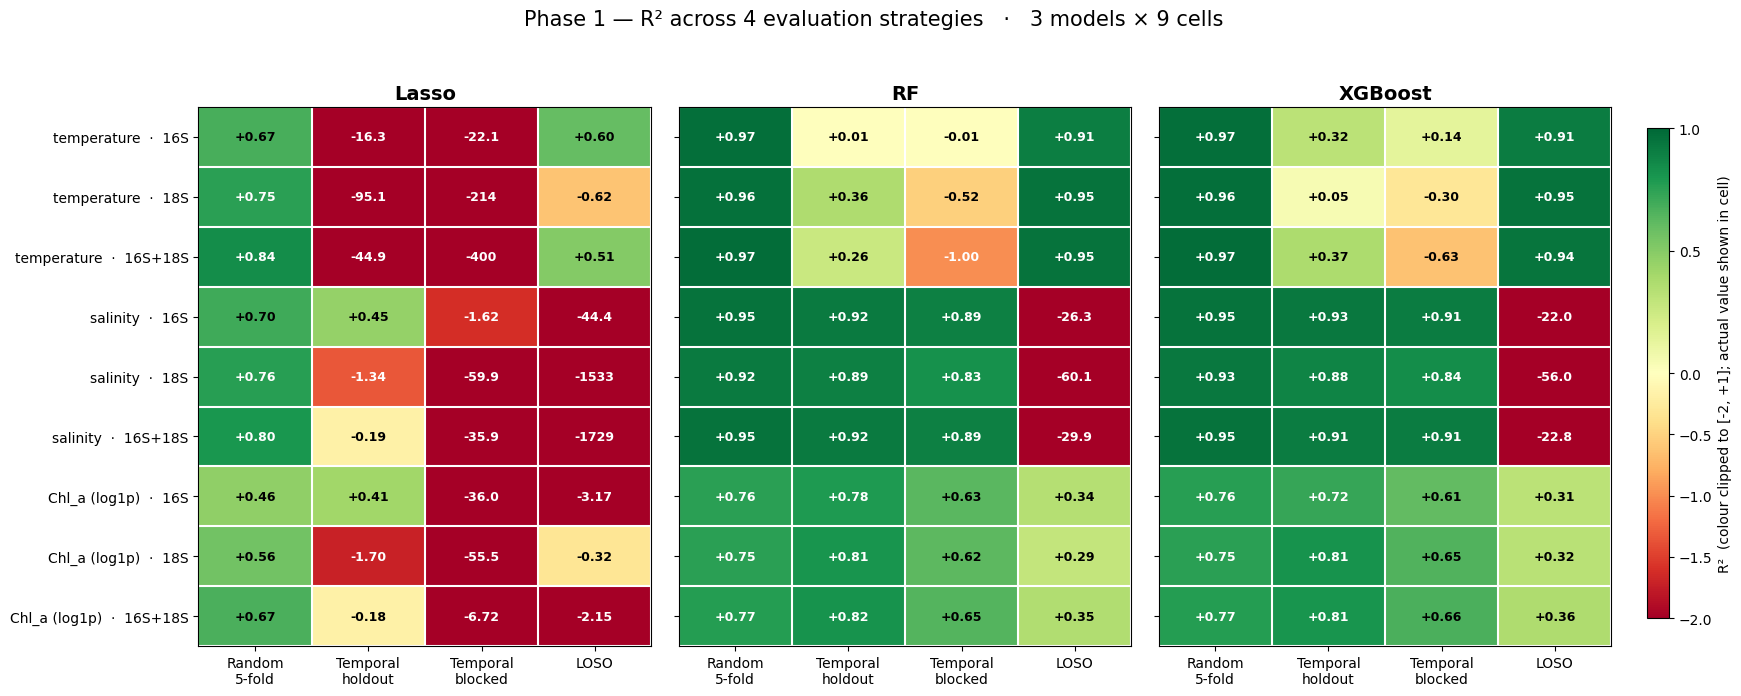


✓ Saved figure to: ../results/phase1_3model_heatmap.png


In [19]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import TwoSlopeNorm

# Column order: same as in the meeting summary doc (easy → hard validation)
_strategy_order  = ['random_kfold', 'temporal_holdout',
                    'temporal_blocked_kfold', 'leave_one_site_out']
_strategy_labels = ['Random\n5-fold', 'Temporal\nholdout',
                    'Temporal\nblocked', 'LOSO']

# Row order: natural physical order — temperature → salinity → Chl_a (skin: warmer → cooler proxy)
_target_order = ['temperature', 'salinity', 'Chl_a (log1p)']
_input_order  = ['16S', '18S', '16S+18S']
_row_index    = pd.MultiIndex.from_product(
    [_target_order, _input_order], names=['target_name', 'input']
)

# Build pivot tables (one per model), reindexed to common row + column order
_pivots = {}
for _model_name in ['Lasso', 'RF', 'XGBoost']:
    _sub = comparison_df[comparison_df['model'] == _model_name]
    _pv = _sub.pivot_table(
        index=['target_name', 'input'],
        columns='strategy',
        values='r2_mean',
    )
    _pivots[_model_name] = _pv.reindex(index=_row_index)[_strategy_order]

# ─── Figure: 3 panels side-by-side ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

# Diverging colormap, clipped to [-2, +1]
# (R² can go very negative, but for visualisation we clip; actual values annotated)
_norm = TwoSlopeNorm(vmin=-2.0, vcenter=0.0, vmax=1.0)
_cmap = 'RdYlGn'

for _ax, _model_name in zip(axes, ['Lasso', 'RF', 'XGBoost']):
    _data    = _pivots[_model_name].values
    _clipped = np.clip(_data, -2.0, 1.0)

    _im = _ax.imshow(_clipped, cmap=_cmap, norm=_norm, aspect='auto')

    # Annotate each cell with actual R² value
    for i in range(_data.shape[0]):
        for j in range(_data.shape[1]):
            _v = _data[i, j]
            if   abs(_v) >= 100:  _txt = f'{_v:.0f}'      # big magnitude, no decimal
            elif abs(_v) >= 10:   _txt = f'{_v:+.1f}'     # 1 decimal
            else:                 _txt = f'{_v:+.2f}'     # 2 decimals
            _txt_color = 'white' if abs(_clipped[i, j]) >= 0.7 else 'black'
            _ax.text(j, i, _txt, ha='center', va='center',
                     color=_txt_color, fontsize=9, fontweight='bold')

    _ax.set_title(_model_name, fontsize=14, fontweight='bold')
    _ax.set_xticks(range(len(_strategy_order)))
    _ax.set_xticklabels(_strategy_labels, fontsize=10)
    _ax.set_yticks(range(len(_row_index)))
    if _ax is axes[0]:
        _ax.set_yticklabels(
            [f'{t}  ·  {i}' for t, i in _row_index], fontsize=10
        )
    else:
        _ax.set_yticklabels([])

    # Subtle white grid between cells
    _ax.set_xticks(np.arange(len(_strategy_order) + 1) - 0.5, minor=True)
    _ax.set_yticks(np.arange(len(_row_index) + 1) - 0.5, minor=True)
    _ax.grid(which='minor', color='white', linewidth=1.5)
    _ax.tick_params(which='minor', bottom=False, left=False)

# Shared colorbar on the right
fig.subplots_adjust(right=0.91, wspace=0.06)
_cbar_ax = fig.add_axes([0.93, 0.15, 0.012, 0.7])
_cbar    = fig.colorbar(_im, cax=_cbar_ax)
_cbar.set_label('R²  (colour clipped to [-2, +1]; actual value shown in cell)',
                fontsize=10)

fig.suptitle(
    'Phase 1 — R² across 4 evaluation strategies   ·   3 models × 9 cells',
    fontsize=15, y=1.02,
)

# Save
_fig_path = Path('../results/phase1_3model_heatmap.png')
plt.savefig(_fig_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved figure to: {_fig_path}")

In [20]:
# Build wide-form comparison (each row = one cell, columns = each model's R²)
# Then compute deltas and identify wins.

wide_df = comparison_df.pivot_table(
    index=['target_name', 'input', 'strategy'],
    columns='model',
    values='r2_mean',
).reset_index()

# Deltas (positive Δ means RF wins; negative means the other model wins)
wide_df['delta_RF_XGB']   = wide_df['RF'] - wide_df['XGBoost']
wide_df['delta_RF_Lasso'] = wide_df['RF'] - wide_df['Lasso']

# ─── Pivot of Δ (RF − XGB) in the same 9×4 layout as the heatmap ────────
_delta_pivot = wide_df.pivot_table(
    index=['target_name', 'input'],
    columns='strategy',
    values='delta_RF_XGB',
).reindex(index=_row_index)[_strategy_order]

print("Δ  =  R²(RF) − R²(XGBoost)    (positive → RF wins,  negative → XGB wins)")
print("=" * 100)
print(_delta_pivot.round(3).to_string())

# ─── Win / tie / loss counts ────────────────────────────────────────────
_d = wide_df['delta_RF_XGB']
_n_rf_wins  = (_d >  0.01).sum()
_n_xgb_wins = (_d < -0.01).sum()
_n_ties     = (_d.abs() <= 0.01).sum()

print(f"\n{'=' * 60}")
print(f"Win counts across 36 cells  (tie if |Δ| ≤ 0.01)")
print(f"{'=' * 60}")
print(f"  RF wins:      {_n_rf_wins:2d} / 36")
print(f"  XGB wins:     {_n_xgb_wins:2d} / 36")
print(f"  Tied:         {_n_ties:2d} / 36")

# ─── Mean Δ — split by regime to avoid catastrophic cells dominating ───
_both_positive = (wide_df['RF'] > 0) & (wide_df['XGBoost'] > 0)
print(f"\nMean Δ (RF − XGB):")
print(f"  All 36 cells:                  {_d.mean():+.4f}")
print(f"  Both models R² > 0  ({_both_positive.sum()}/36):  "
      f"{wide_df.loc[_both_positive, 'delta_RF_XGB'].mean():+.4f}")

# ─── By strategy ────────────────────────────────────────────────────────
print(f"\nMean Δ by strategy (positive → RF wins on average):")
for _strat in _strategy_order:
    _sub = wide_df[wide_df['strategy'] == _strat]['delta_RF_XGB']
    print(f"  {_strat:25s}  mean={_sub.mean():+.4f}   "
          f"median={_sub.median():+.4f}   "
          f"wins(RF/XGB/tie)={(_sub > 0.01).sum()}/"
          f"{(_sub < -0.01).sum()}/{(_sub.abs() <= 0.01).sum()}")

# ─── Top 5 wins per side ────────────────────────────────────────────────
print(f"\n{'─' * 100}")
print("Top 5 cells where RF wins:")
_display_cols = ['target_name', 'input', 'strategy', 'Lasso', 'RF', 'XGBoost', 'delta_RF_XGB']
print(wide_df.nlargest(5, 'delta_RF_XGB')[_display_cols].to_string(index=False))

print(f"\nTop 5 cells where XGBoost wins:")
print(wide_df.nsmallest(5, 'delta_RF_XGB')[_display_cols].to_string(index=False))

Δ  =  R²(RF) − R²(XGBoost)    (positive → RF wins,  negative → XGB wins)
strategy               random_kfold  temporal_holdout  temporal_blocked_kfold  leave_one_site_out
target_name   input                                                                              
temperature   16S            -0.003            -0.308                  -0.144              -0.007
              18S            -0.005             0.318                  -0.225              -0.002
              16S+18S        -0.002            -0.110                  -0.371               0.008
salinity      16S            -0.002            -0.005                  -0.017              -4.337
              18S            -0.010             0.018                  -0.018              -4.131
              16S+18S        -0.002             0.006                  -0.018              -7.106
Chl_a (log1p) 16S            -0.007             0.063                   0.021               0.023
              18S             0.001          

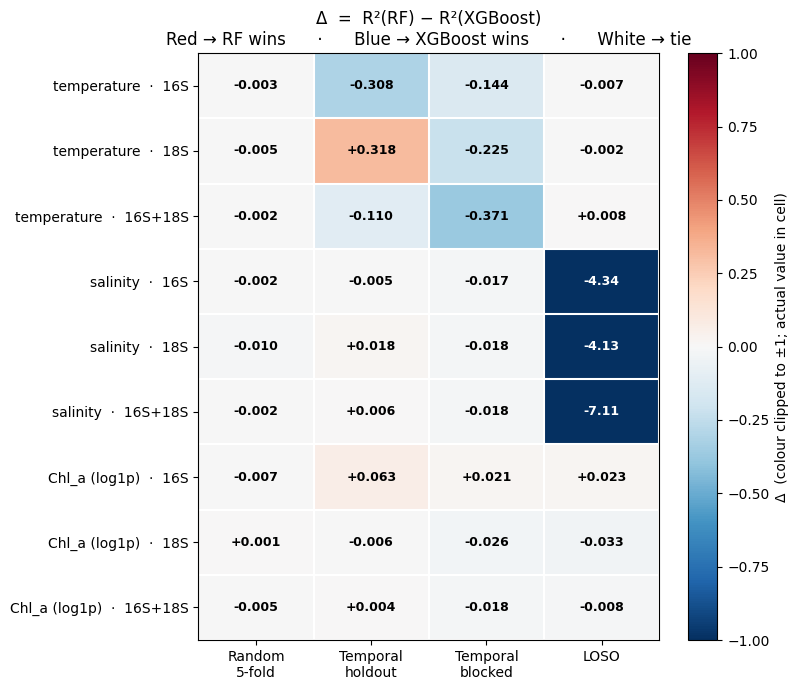


✓ Saved figure to: ../results/phase1_delta_rf_minus_xgb.png


In [21]:
# Visual Δ heatmap: where each model wins, by cell.
# Same 9 × 4 layout as Cell 19 but coloured by Δ instead of absolute R².

fig, ax = plt.subplots(1, 1, figsize=(8, 7))

_delta_data = _delta_pivot.values

# Diverging colormap centred at 0; clipped to ±1 for visualisation
_clip = 1.0
_norm = TwoSlopeNorm(vmin=-_clip, vcenter=0.0, vmax=_clip)
_im = ax.imshow(
    np.clip(_delta_data, -_clip, _clip),
    cmap='RdBu_r', norm=_norm, aspect='auto'
)

# Annotate each cell with actual Δ value
for i in range(_delta_data.shape[0]):
    for j in range(_delta_data.shape[1]):
        _v = _delta_data[i, j]
        if abs(_v) >= 1:    _txt = f'{_v:+.2f}'
        else:               _txt = f'{_v:+.3f}'
        _clipped = np.clip(_v, -_clip, _clip)
        _txt_color = 'white' if abs(_clipped) >= 0.6 else 'black'
        ax.text(j, i, _txt, ha='center', va='center',
                color=_txt_color, fontsize=9, fontweight='bold')

ax.set_title(
    'Δ  =  R²(RF) − R²(XGBoost)\n'
    'Red → RF wins      ·      Blue → XGBoost wins      ·      White → tie',
    fontsize=12,
)
ax.set_xticks(range(len(_strategy_order)))
ax.set_xticklabels(_strategy_labels)
ax.set_yticks(range(len(_row_index)))
ax.set_yticklabels([f'{t}  ·  {i}' for t, i in _row_index])

# Grid between cells
ax.set_xticks(np.arange(len(_strategy_order) + 1) - 0.5, minor=True)
ax.set_yticks(np.arange(len(_row_index) + 1) - 0.5, minor=True)
ax.grid(which='minor', color='white', linewidth=1.5)
ax.tick_params(which='minor', bottom=False, left=False)

fig.colorbar(_im, ax=ax, label='Δ  (colour clipped to ±1; actual value in cell)')
plt.tight_layout()

_fig_path = Path('../results/phase1_delta_rf_minus_xgb.png')
plt.savefig(_fig_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved figure to: {_fig_path}")

### Section 3 — Summary of three-model comparison

**Headline:**
- **Lasso ≪ RF ≈ XGBoost.** Non-linearity is the dominant factor; whether by
  averaging (RF) or sequential error correction (XGBoost) matters only on
  specific cells.
- **Win counts (36 cells):** RF 5 · Tied 17 · XGB 14
- **Mean Δ in operating regime** (both models R² > 0, 30/36 cells): **−0.005** —
  practically indistinguishable.

**Where XGBoost wins:**
1. **`salinity × LOSO`** (Δ = −4 to −7): when extrapolating to Muehlendamm, both
   models fail, but XGBoost predictions stay slightly more bounded
   (R² ≈ −22 to −60 vs RF's −26 to −60; vs Lasso's −44 to −1729).
2. **`temperature × temporal_blocked`** (Δ = −0.14 to −0.37): held-out seasonal
   blocks favour boosting's sequential error correction.

**Where RF wins (surprising):**
1. **`temperature × 18S × temporal_holdout`**: Δ = +0.318  (RF 0.36 vs XGB 0.05).
   With eukaryotic markers, the seasonal pattern is less smoothly temporal, so
   boosting's incremental learning gains less ground than RF's averaging.
2. **`Chl_a × 16S` under realistic validation**: Δ = +0.02 to +0.06 on holdout,
   blocked, and LOSO. Small but consistent.

**By strategy:**
- `random_kfold`: 0/0/9 (9 ties out of 9) — random splits hide all differences
- `temporal_holdout`: 3/2/4 — close race
- `temporal_blocked_kfold`: 1/8/0 — XGBoost clearly wins (temperature drives this)
- `leave_one_site_out`: 1/4/4 — XGBoost edge, mostly from salinity Muehlendamm

**For the thesis narrative:**
The previous claim "XGBoost wins every cell, 36 of 36" was against Lasso only.
With RF added, the picture is: **two non-linear models perform essentially
identically on 47% of cells (ties); when they differ, the choice is
task-specific.** This reframes the model comparison from a horse race into a
discussion of *which model class fits which prediction problem*.